In [60]:
import numpy as np 
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 
from tqdm import tqdm 
from sklearn.metrics import log_loss, accuracy_score

In [61]:
def initialisation(dimensions):

    parametres = {}
    C = len(dimensions) 

    for c in range(1, C) : 
        parametres['W' + str(c)] = np.random.randn(dimensions[c], dimensions[c - 1])
        parametres['b' + str(c)] = np.random.randn(dimensions[c], 1)

    return parametres

In [62]:
parametres = initialisation([2, 32, 32, 1])

for key, val in parametres.items(): 
    print(key, val.shape)

W1 (32, 2)
b1 (32, 1)
W2 (32, 32)
b2 (32, 1)
W3 (1, 32)
b3 (1, 1)


In [63]:
def forward_propagation(X, parametres):

    activations = {'A0' : X}

    C = len(parametres) // 2 

    for c in range(1, C+1):
        Z = parametres['W' + str(c)].dot(activations['A' + str(c - 1)]) + parametres['b' + str(c)]
        activations['A' + str(c)] = 1 / (1 + np.exp(-Z))

    return activations



In [64]:
X = np.random.randn(100, 2).T # taille features * examplles

In [65]:
activations = forward_propagation(X, parametres)

for key, val in activations.items(): 
    print(key, val.shape)

A0 (2, 100)
A1 (32, 100)
A2 (32, 100)
A3 (1, 100)


In [66]:
def back_propagation(y, activations, parametres): 

    m = y.shape[1] 
    C = len(parametres) // 2

    dZ = activations['A' + str(C)] - y 
    gradients = {}

    for c in reversed(range(1, C + 1)): 
        gradients['dW' + str(c)] = 1 / m * np.dot(dZ, activations['A' + str(c - 1)].T)
        gradients['db' + str(c)] = 1 / m * np.sum(dZ, axis=1, keepdims=True)
        if c > 1: 
            dZ = np.dot(parametres['W' + str(c)].T, dZ) * activations['A' + str(c - 1)] * (1 - activations['A' + str(c - 1)])
        
    
    return gradients

In [67]:
y = np.random.randn(1, X.shape[1])

In [68]:
grad = back_propagation(y, activations, parametres)

for key, val in grad.items(): 
    print(key, val.shape)

dW3 (1, 32)
db3 (1, 1)
dW2 (32, 32)
db2 (32, 1)
dW1 (32, 2)
db1 (32, 1)


In [69]:
def update(gradients, parametres, learning_rate): 

    C = len(parametres) // 2 

    for c in range(1, C + 1): 
        parametres['W' + str(c)] = parametres['W' + str(c)] 
        parametres['b' + str(c)] = parametres['b' + str(c)] 
    
    return parametres

In [70]:
def predict(X, parametres): 
    activations = forward_propagation(X, parametres)
    C = len(parametres) // 2 
    Af = activations['A' + str(C)]
    return Af >=0.5

In [72]:
def neural_network(X, y, hidden_layers = (32, 32, 32), learning_rate= 0.1, n_iter = 1000): 

    np.random.seed(0) 
    # initialisation W, b 
    dimensions = list(hidden_layers) 
    dimensions.insert(0, X.shape[0])
    dimensions.append(y.shape[0])
    parametres = initialisation(dimensions)

    train_loss = [] 
    train_acc = [] 

    for i in tqdm(range(n_iter)): 

        activations = forward_propagation(X, parametres)
        gradients = back_propagation(y, activations, parametres)
        parametres = update(gradients, parametres, learning_rate)

        if i%10 == 0: 
            C = len(parametres) // 2 
            train_loss.append(log_loss(y, activations['A' + str(C)]))
            y_pred = predict(X, parametres) 
            current_accuracy = accuracy_score(y.flatten(), y_pred.flatten())
            train_acc.append(current_accuracy)
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 4))
    ax[0].plot(train_loss, label='train loss')
    ax[0].legend() 

    ax[1].plot(train_acc, label = 'train acc')
    ax[1].legend()

    return parametres

In [73]:
from sklearn.datasets import make_circles

dimensions de X: (2, 100)
dimensions de y: (1, 100)


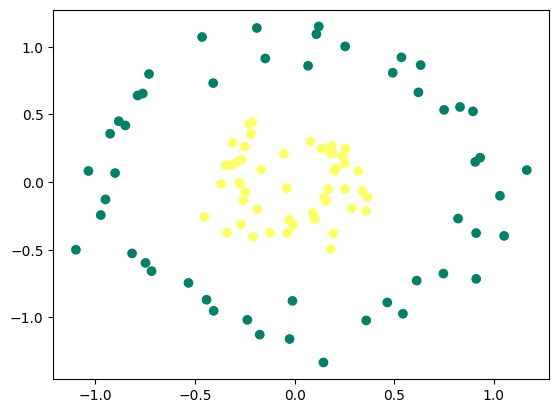

In [74]:
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[0, :], X[1, :], c=y, cmap='summer')
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/

{'W1': array([[ 1.76405235,  0.40015721],
        [ 0.97873798,  2.2408932 ],
        [ 1.86755799, -0.97727788],
        [ 0.95008842, -0.15135721],
        [-0.10321885,  0.4105985 ],
        [ 0.14404357,  1.45427351],
        [ 0.76103773,  0.12167502],
        [ 0.44386323,  0.33367433],
        [ 1.49407907, -0.20515826],
        [ 0.3130677 , -0.85409574],
        [-2.55298982,  0.6536186 ],
        [ 0.8644362 , -0.74216502],
        [ 2.26975462, -1.45436567],
        [ 0.04575852, -0.18718385],
        [ 1.53277921,  1.46935877],
        [ 0.15494743,  0.37816252]]),
 'b1': array([[-0.88778575],
        [-1.98079647],
        [-0.34791215],
        [ 0.15634897],
        [ 1.23029068],
        [ 1.20237985],
        [-0.38732682],
        [-0.30230275],
        [-1.04855297],
        [-1.42001794],
        [-1.70627019],
        [ 1.9507754 ],
        [-0.50965218],
        [-0.4380743 ],
        [-1.25279536],
        [ 0.77749036]]),
 'W2': array([[-1.61389785, -0.21274028,

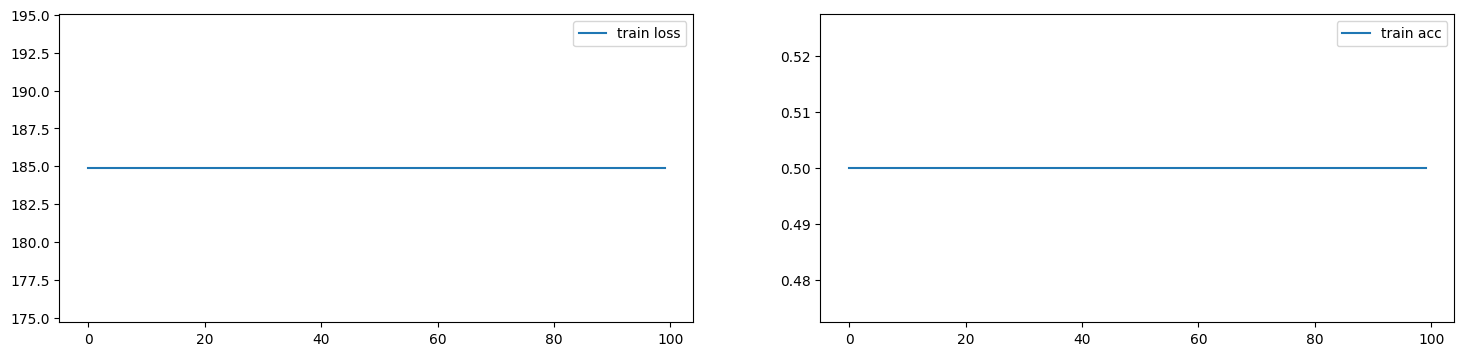

In [75]:
neural_network(X, y, hidden_layers=(16,16,16))